# Huấn luyện và Đánh giá Mô hình Dự báo Revenue & COGS
**Ngày thực hiện:** 02/06/2026  
**Mục tiêu:** Xây dựng pipeline modeling để dự báo `Revenue` và `COGS` theo ngày, so sánh Baseline (Ridge) với mô hình Boosting (LightGBM).

**Dữ liệu đầu vào:**
- `X_train`, `X_valid`: Tập đặc trưng đã được chuẩn bị (leakage-safe).
- `y_train`, `y_valid`: Biến mục tiêu `Revenue` và `COGS`.
- `selected_features_final.csv`: Danh sách 11 đặc trưng tối ưu đã chọn lọc.

## 1. Import Thư viện & Thiết lập

In [1]:

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import ds_utils as du

try:
    from sklearn.linear_model import Ridge, ElasticNet
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import HistGradientBoostingRegressor
    HAS_SKLEARN = True
except ImportError:
    Ridge = ElasticNet = StandardScaler = HistGradientBoostingRegressor = None
    HAS_SKLEARN = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    lgb = None
    HAS_LGB = False

try:
    import joblib
    HAS_JOBLIB = True
except ImportError:
    joblib = None
    HAS_JOBLIB = False

du.setup_notebook()
RANDOM_SEED = 42
DATE_COL = "Date"
TARGETS = ["Revenue", "COGS"]

REPORT_DIR = PROJECT_ROOT / "report_2_6_2026"
MODEL_OUT_DIR = REPORT_DIR / "models"
REPORT_OUT_DIR = REPORT_DIR / "reports"
IMAGE_OUT_DIR = REPORT_DIR / "images"
for path in [MODEL_OUT_DIR, REPORT_OUT_DIR, IMAGE_OUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

setup_report = pd.DataFrame([
    ["project_root", str(PROJECT_ROOT)],
    ["report_dir", str(REPORT_DIR)],
    ["scikit-learn_available", HAS_SKLEARN],
    ["lightgbm_available", HAS_LGB],
    ["joblib_available", HAS_JOBLIB],
], columns=["item", "value"])

_ = du.show(setup_report, title="Environment setup")



Environment setup
                     item                                        value
0            project_root                  B:\Dự án VSF\VinuniDatathon
1              report_dir  B:\Dự án VSF\VinuniDatathon\report_2_6_2026
2  scikit-learn_available                                        False
3      lightgbm_available                                        False
4        joblib_available                                        False


## 2. Cấu hình Đường dẫn & Load Dữ liệu

Sử dụng các artifact đã được chuẩn bị từ bước Data Preparation.

In [2]:

DATA_DIR = PROJECT_ROOT / "report_1_6_2026/outputs/data_preparation_daily"
FEATURE_FILE = PROJECT_ROOT / "report_1_6_2026/outputs/feature_analysis_focused/selected_features_final.csv"

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(f"Missing train/test files in {DATA_DIR}. Run report_1_6_2026/perparation_data_update.ipynb first.")
if not FEATURE_FILE.exists():
    raise FileNotFoundError(f"Missing selected feature file: {FEATURE_FILE}")

train_data = pd.read_csv(train_path, parse_dates=[DATE_COL])
valid_data = pd.read_csv(test_path, parse_dates=[DATE_COL])

selected_features_df = pd.read_csv(FEATURE_FILE)
selected_features = selected_features_df["feature"].tolist()

y_train_rev_s = train_data["Revenue"].astype(float)
y_valid_rev_s = valid_data["Revenue"].astype(float)
y_train_cogs_s = train_data["COGS"].astype(float)
y_valid_cogs_s = valid_data["COGS"].astype(float)

load_summary = pd.DataFrame([
    ["train.csv", len(train_data), train_data.shape[1], train_data[DATE_COL].min(), train_data[DATE_COL].max()],
    ["test.csv", len(valid_data), valid_data.shape[1], valid_data[DATE_COL].min(), valid_data[DATE_COL].max()],
    ["selected_features", len(selected_features), np.nan, np.nan, np.nan],
], columns=["item", "rows_or_count", "cols", "date_min", "date_max"])

_ = du.show(load_summary, title="Loaded modeling inputs")



Loaded modeling inputs
                item  rows_or_count  cols   date_min   date_max
0          train.csv           3103  14.0 2012-07-04 2020-12-31
1           test.csv            730  14.0 2021-01-01 2022-12-31
2  selected_features             11   NaN        NaT        NaT


## 3. Kiểm tra Tính sẵn sàng & Preprocessing

Đảm bảo không có leakage và các feature cần thiết đều có mặt.

In [3]:
# Validate feature schema and create imputed/scaled matrices
missing_train_features = [f for f in selected_features if f not in train_data.columns]
missing_test_features = [f for f in selected_features if f not in valid_data.columns]
if missing_train_features or missing_test_features:
    raise ValueError({
        "missing_train_features": missing_train_features,
        "missing_test_features": missing_test_features,
    })

X_train_final = train_data[selected_features].copy()
X_valid_final = valid_data[selected_features].copy()

train_medians = X_train_final.median(numeric_only=True)
X_train_model = X_train_final.fillna(train_medians).astype(float)
X_valid_model = X_valid_final.fillna(train_medians).astype(float)

x_mean = X_train_model.mean(axis=0)
x_std = X_train_model.std(axis=0).replace(0, 1)
X_train_scaled = ((X_train_model - x_mean) / x_std).to_numpy(float)
X_valid_scaled = ((X_valid_model - x_mean) / x_std).to_numpy(float)

readiness_report = pd.DataFrame([
    ["train_rows", len(X_train_model)],
    ["test_rows", len(X_valid_model)],
    ["features", len(selected_features)],
    ["train_missing_after_impute", int(X_train_model.isna().sum().sum())],
    ["test_missing_after_impute", int(X_valid_model.isna().sum().sum())],
], columns=["check", "value"])
_ = du.show(readiness_report, title="Model input readiness")


Model input readiness
                        check  value
0                  train_rows   3103
1                   test_rows    730
2                    features     11
3  train_missing_after_impute      0
4   test_missing_after_impute      0


## 4. Xây dựng Baseline (Naive & Ridge)

Sử dụng Naive (Lag-1) và Ridge Regression làm sàn so sánh.

In [4]:

def evaluate(name, target, y_true, y_pred):
    metrics = du.regression_metrics(y_true, y_pred)
    metrics["name"] = name
    metrics["target"] = target
    return metrics

def fit_ridge_numpy(X, y, alpha=10.0):
    X_design = np.c_[np.ones(len(X)), X]
    penalty = np.eye(X_design.shape[1]) * alpha
    penalty[0, 0] = 0.0
    return np.linalg.pinv(X_design.T @ X_design + penalty) @ X_design.T @ y

def predict_ridge_numpy(coef, X):
    return np.c_[np.ones(len(X)), X] @ coef

results = []

results.append(evaluate("Naive_lag_1d", "Revenue", y_valid_rev_s, X_valid_model["Revenue_lag_1d"]))
results.append(evaluate("Naive_lag_1d", "COGS", y_valid_cogs_s, X_valid_model["COGS_lag_1d"]))

if HAS_SKLEARN:
    ridge_rev = Ridge(alpha=10.0)
    ridge_cogs = Ridge(alpha=10.0)
    ridge_rev.fit(X_train_scaled, y_train_rev_s)
    ridge_cogs.fit(X_train_scaled, y_train_cogs_s)
    pred_ridge_rev = ridge_rev.predict(X_valid_scaled)
    pred_ridge_cogs = ridge_cogs.predict(X_valid_scaled)
    ridge_backend = "sklearn.Ridge"
else:
    ridge_rev = fit_ridge_numpy(X_train_scaled, y_train_rev_s.to_numpy(float), alpha=10.0)
    ridge_cogs = fit_ridge_numpy(X_train_scaled, y_train_cogs_s.to_numpy(float), alpha=10.0)
    pred_ridge_rev = predict_ridge_numpy(ridge_rev, X_valid_scaled)
    pred_ridge_cogs = predict_ridge_numpy(ridge_cogs, X_valid_scaled)
    ridge_backend = "numpy_ridge"

results.append(evaluate("Ridge", "Revenue", y_valid_rev_s, pred_ridge_rev))
results.append(evaluate("Ridge", "COGS", y_valid_cogs_s, pred_ridge_cogs))

baseline_comparison = pd.DataFrame(results)
baseline_comparison.insert(0, "stage", "baseline")
baseline_summary = baseline_comparison.copy()
baseline_summary["backend"] = baseline_summary["name"].map({"Naive_lag_1d": "lag_1d_rule", "Ridge": ridge_backend})

_ = du.show(
    baseline_summary[["stage", "name", "backend", "target", "mae", "rmse", "wape"]],
    title="Baseline and Ridge validation metrics",
)



Baseline and Ridge validation metrics
      stage          name      backend   target            mae          rmse      wape
0  baseline  Naive_lag_1d  lag_1d_rule  Revenue  686699.669712  1.039280e+06  0.226543
1  baseline  Naive_lag_1d  lag_1d_rule     COGS  613707.158548  9.319706e+05  0.228394
2  baseline         Ridge  numpy_ridge  Revenue  619282.703467  9.424121e+05  0.204302
3  baseline         Ridge  numpy_ridge     COGS  554762.841837  8.502009e+05  0.206458


## 5. Huấn luyện Mô hình chính (Boosting)

Sử dụng LightGBM (hoặc HistGradientBoosting fallback).

In [5]:

if HAS_LGB:
    model_rev = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        random_state=RANDOM_SEED, verbose=-1
    )
    model_cogs = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        random_state=RANDOM_SEED, verbose=-1
    )
    model_backend = "LightGBM"
elif HAS_SKLEARN:
    model_rev = HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_depth=6,
        random_state=RANDOM_SEED
    )
    model_cogs = HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_depth=6,
        random_state=RANDOM_SEED
    )
    model_backend = "HistGradientBoostingRegressor"
else:
    model_rev = fit_ridge_numpy(X_train_scaled, y_train_rev_s.to_numpy(float), alpha=3.0)
    model_cogs = fit_ridge_numpy(X_train_scaled, y_train_cogs_s.to_numpy(float), alpha=3.0)
    model_backend = "numpy_ridge_fallback"

if model_backend == "numpy_ridge_fallback":
    pred_boost_rev = predict_ridge_numpy(model_rev, X_valid_scaled)
    pred_boost_cogs = predict_ridge_numpy(model_cogs, X_valid_scaled)
else:
    model_rev.fit(X_train_model, y_train_rev_s)
    model_cogs.fit(X_train_model, y_train_cogs_s)
    pred_boost_rev = model_rev.predict(X_valid_model)
    pred_boost_cogs = model_cogs.predict(X_valid_model)

main_model_results = pd.DataFrame([
    evaluate("Main_model", "Revenue", y_valid_rev_s, pred_boost_rev),
    evaluate("Main_model", "COGS", y_valid_cogs_s, pred_boost_cogs),
])
main_model_results.insert(0, "stage", "main_model")
main_model_results["backend"] = model_backend

model_comparison = pd.concat([baseline_summary, main_model_results], ignore_index=True)

_ = du.show(
    main_model_results[["stage", "name", "backend", "target", "mae", "rmse", "wape"]],
    title="Main model validation metrics",
)



Main model validation metrics
        stage        name               backend   target            mae           rmse      wape
0  main_model  Main_model  numpy_ridge_fallback  Revenue  623402.841705  945566.287818  0.205661
1  main_model  Main_model  numpy_ridge_fallback     COGS  555723.065544  850750.384244  0.206815


## 6. Trực quan hóa & Phân tích Sai số

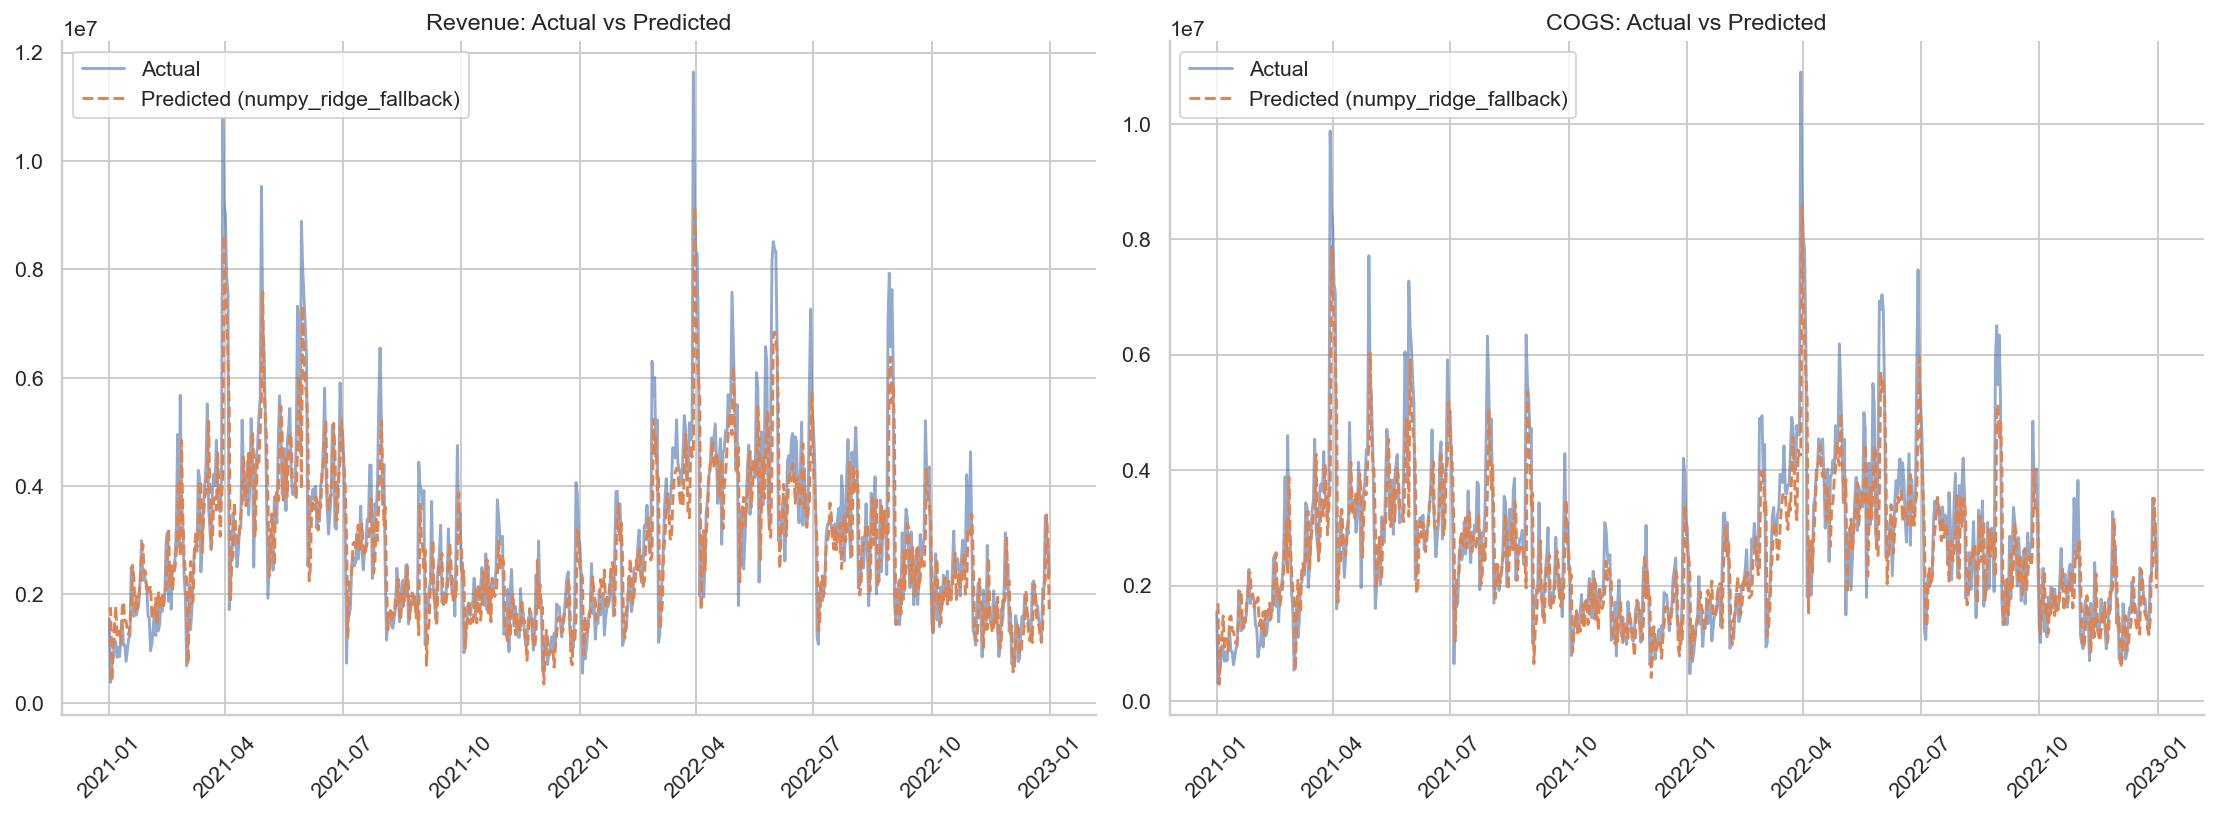

In [6]:

plt.close("all")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(valid_data[DATE_COL], y_valid_rev_s, label="Actual", alpha=0.6)
axes[0].plot(valid_data[DATE_COL], pred_boost_rev, label=f"Predicted ({model_backend})", linestyle="--")
axes[0].set_title("Revenue: Actual vs Predicted")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(valid_data[DATE_COL], y_valid_cogs_s, label="Actual", alpha=0.6)
axes[1].plot(valid_data[DATE_COL], pred_boost_cogs, label=f"Predicted ({model_backend})", linestyle="--")
axes[1].set_title("COGS: Actual vs Predicted")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plot_path = IMAGE_OUT_DIR / "actual_vs_pred.png"
plt.savefig(plot_path, dpi=140, bbox_inches="tight")
plt.show()
plt.close(fig)


## 7. Export Kết quả & Submission

Lưu mô hình và tạo file submission cho tập horizon.

In [7]:

model_comparison_path = REPORT_OUT_DIR / "model_comparison.csv"
predictions_path = REPORT_OUT_DIR / "holdout_predictions.csv"

export_model_comparison = model_comparison[["mae", "rmse", "wape", "name", "target", "backend", "stage"]].copy()
export_model_comparison.to_csv(model_comparison_path, index=False)

holdout_predictions = pd.DataFrame({
    DATE_COL: valid_data[DATE_COL],
    "Revenue_actual": y_valid_rev_s,
    "Revenue_pred": np.maximum(0, pred_boost_rev),
    "COGS_actual": y_valid_cogs_s,
    "COGS_pred": np.maximum(0, pred_boost_cogs),
})
holdout_predictions.to_csv(predictions_path, index=False)

if HAS_JOBLIB and model_backend != "numpy_ridge_fallback":
    joblib.dump(model_rev, MODEL_OUT_DIR / "revenue_model.joblib")
    joblib.dump(model_cogs, MODEL_OUT_DIR / "cogs_model.joblib")
    model_saved = True
else:
    model_saved = False

sample_submission_path = PROJECT_ROOT / "data/sample_submission.csv"
submission_status = "available_but_deferred" if sample_submission_path.exists() else "not_found"

export_manifest = pd.DataFrame([
    ["model_comparison.csv", model_comparison_path.name, export_model_comparison.shape[0]],
    ["holdout_predictions.csv", predictions_path.name, holdout_predictions.shape[0]],
    ["actual_vs_pred.png", plot_path.name, "saved"],
    ["model_files_saved", "models", model_saved],
    ["sample_submission", "data/sample_submission.csv", submission_status],
], columns=["artifact", "file", "rows_or_status"])

_ = du.show(export_manifest, title="Export manifest")



Export manifest
                  artifact                        file          rows_or_status
0     model_comparison.csv        model_comparison.csv                       6
1  holdout_predictions.csv     holdout_predictions.csv                     730
2       actual_vs_pred.png          actual_vs_pred.png                   saved
3        model_files_saved                      models                   False
4        sample_submission  data/sample_submission.csv  available_but_deferred
